![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Análisis de sentimientos y técnicas de NLP

En este taller podrán poner en práctica sus conocimientos sobre las diferentes técnicas para el procesamiento de lenguaje natural. El taller está constituido por 5 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción sentimientos de viajeros en Twitter

En este taller se usará el conjunto de datos de sentimientos sobre distintas aerolíneas de EE.UU. provenientes de Twitter. Cada observación contiene si el sentimiento de los tweets es positivo, neutral o negativo teniendo en cuenta distintas variables como aerolínea y las razones de los sentimientos negativos (como "retraso en el vuelo" o "servicio grosero"). El objetivo es predecir el sentimiento asociado a cada tweet. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/crowdflower/twitter-airline-sentiment).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación de librerías
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import zipfile
import io
import requests
import nltk

In [3]:
from sklearn.metrics import accuracy_score
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

In [4]:
# Lectura de la información de archivo .zip
tweets = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/Tweets.zip', index_col=0)

# Visualización dataset
tweets.head()

,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
tweet_id,,,,,,,,,,,,,,
570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [5]:
# Impresión tamaño del cojunto de datos
tweets.shape

(14640, 14)

### Análisis descriptivo

In [6]:
# Cuenta de tweets por cada sentimiento
tweets['airline_sentiment'].value_counts()

negative    9178
neutral     3099
positive    2363
Name: airline_sentiment, dtype: int64

In [7]:
# Cuenta de tweets por cada aerolínea
tweets['airline'].value_counts()

United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: airline, dtype: int64

In [8]:
# leer url
url = 'https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/Tweets.zip'
resp = requests.get(url)

# Abrir el archivo dentro del zip
z = zipfile.ZipFile(io.BytesIO(resp.content))
tweets = pd.read_csv(z.open('Tweets.csv'), index_col=0)

# Resetear indice para eliminar duplicados
tweets = tweets.reset_index(drop=True)

tweets.head()

,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


<Axes: title={'center': 'Sentiminetos por aerolínea'}, xlabel='airline'>

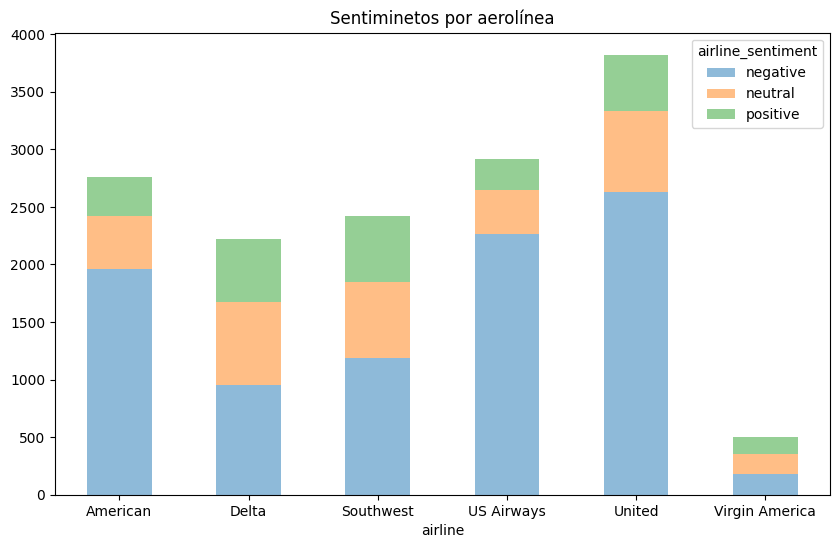

In [9]:
# Plot con cuenta de tweets por cada aerolínea y sentimiento
pd.crosstab(index = tweets["airline"],columns = tweets["airline_sentiment"]).plot(kind='bar',figsize=(10, 6),alpha=0.5,rot=0,stacked=True,title="Sentiminetos por aerolínea")

### Liberias y Variables de interés y predicción

In [10]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from nltk.stem.snowball import SnowballStemmer
from nltk.stem import WordNetLemmatizer

In [11]:
# Separación de variables predictoras (X) y de variable de interés (y)
X = tweets['text']
y = tweets['airline_sentiment'].map({'negative':-1,'neutral':0,'positive':1})

In [12]:
# Separación de datos en set de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Uso de CountVectorizer

En la celda 1 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [13]:
# Crear vectorizador
count_vectorizer = CountVectorizer(
    lowercase=True,
    max_features=5000
)

In [14]:
# Ajustar solo con entrenamiento y transformar train
X_train_count = count_vectorizer.fit_transform(X_train)

In [15]:
# Transformar test con el mismo vectorizador
X_test_count = count_vectorizer.transform(X_test)

In [16]:
# Crear modelo Random Forest
modelo_rf = RandomForestClassifier(
    n_estimators=100, # numero de arboles
    random_state=42,
    n_jobs=-1 # todos los nucleos
)

In [17]:
# Entrenar modelo
modelo_rf.fit(X_train_count, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [18]:
# Predecir en test
y_pred_rf = modelo_rf.predict(X_test_count)

In [19]:
# Evaluar con accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy CountVectorizer + RandomForest:", acc_rf)

Accuracy CountVectorizer + RandomForest: 0.7711092715231788


<h3 style='color: deepskyblue;'>Comentario</h3>
Se entrenó un modelo de Random Forest utilizando CountVectorizer con un máximo de 5000 características. El modelo obtuvo un accuracy de 0.7711 en el conjunto de prueba, lo que indica un desempeño aceptable, superior a un modelo base. Sin embargo, al usar únicamente conteo de palabras, el modelo no captura el contexto semántico, lo que limita su capacidad predictiva.

### Punto 2 - Eliminación de Stopwords

En la celda 2 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer, **eliminen stopwords** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [20]:
# Crear vectorizador con eliminación de stopwords
count_vectorizer_sw = CountVectorizer(
    lowercase=True,
    stop_words='english', # eliminación de stopwords
    max_features=5000
)

In [21]:
# Ajustar solo con entrenamiento y transformar train
X_train_count_sw = count_vectorizer_sw.fit_transform(X_train)

In [22]:
# Transformar test con el mismo vectorizador
X_test_count_sw = count_vectorizer_sw.transform(X_test)

In [23]:
# Crear modelo Random Forest
modelo_rf_sw = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [24]:
# Entrenar modelo
modelo_rf_sw.fit(X_train_count_sw, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [25]:
# Predecir en test
y_pred_rf_sw = modelo_rf_sw.predict(X_test_count_sw)

In [26]:
# Evaluar con accuracy
acc_rf_sw = accuracy_score(y_test, y_pred_rf_sw)

print("Accuracy CountVectorizer (stopwords) + RandomForest:", acc_rf_sw)

Accuracy CountVectorizer (stopwords) + RandomForest: 0.7557947019867549


<h3 style='color: deepskyblue;'>Comentario</h3>
Se entrenó un modelo de Random Forest utilizando CountVectorizer eliminando stopwords en inglés. Esta técnica permite reducir el ruido eliminando palabras comunes con significado menos relevante. El modelo obtuvo un accuracy de 0.7558, respecto al modelo sin eliminación de stopwords. Sin embargo, en análisis de sentimientos, eliminar ciertas palabras como “not” puede afectar la interpretación del texto.

### Punto 3 - Lematización con verbos

En la celda 3 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer, **lematizen el texto con verbos** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [27]:
# Descargar recursos necesarios
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')

lemmatizer = WordNetLemmatizer()

def lemmatize_verbs(text):
    tokens = nltk.word_tokenize(text.lower())
    lemmas = [lemmatizer.lemmatize(token, pos=wordnet.VERB) for token in tokens]
    return " ".join(lemmas)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\BIENVENIDO\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\BIENVENIDO\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\BIENVENIDO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\BIENVENIDO\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


In [28]:
# Aplicar lematización a train y test
X_train_lem = X_train.apply(lemmatize_verbs)
X_test_lem = X_test.apply(lemmatize_verbs)

In [29]:
# Crear vectorizador
count_vectorizer_lem = CountVectorizer(
    lowercase=True,
    max_features=5000
)

In [30]:
# Ajustar solo con entrenamiento y transformar train
X_train_count_lem = count_vectorizer_lem.fit_transform(X_train_lem)

In [31]:
# Transformar test con el mismo vectorizador
X_test_count_lem = count_vectorizer_lem.transform(X_test_lem)

In [32]:
# Crear modelo Random Forest
modelo_rf_lem = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [33]:
# Entrenar modelo
modelo_rf_lem.fit(X_train_count_lem, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [34]:
# Predecir en test
y_pred_rf_lem = modelo_rf_lem.predict(X_test_count_lem)

In [35]:
# Evaluar con accuracy
acc_rf_lem = accuracy_score(y_test, y_pred_rf_lem)

print("Accuracy CountVectorizer (lematización verbos) + RandomForest:", acc_rf_lem)

Accuracy CountVectorizer (lematización verbos) + RandomForest: 0.7735927152317881


<h3 style='color: deepskyblue;'>Comentario</h3>
Se aplicó lematización enfocada en verbos para reducir las diferentes formas verbales a su forma base. Posteriormente, se utilizó CountVectorizer y un modelo Random Forest. El modelo obtuvo un accuracy de 0.7736, mostrando una ligera mejora respecto a los enfoques anteriores. Esto sugiere que la normalización de palabras ayuda a reducir la dimensionalidad y mejorar la capacidad predictiva. Sin embargo, al lematizar todas las palabras como verbos, se puede perder precisión semántica.

### Punto 4 - Multiples técnicas

En la celda 4 creen un modelo de random forest con la libreria sklearn que prediga el sentimiento de los tweets usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer, eliminen stopwords, lematizen el texto con verbos** y presenten el desempeño del modelo con la métrica del acurracy.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [36]:
# Descargar recursos necesarios
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')

lemmatizer = WordNetLemmatizer()

def lemmatize_verbs(text):
    tokens = nltk.word_tokenize(text.lower())
    lemmas = [lemmatizer.lemmatize(token, pos=wordnet.VERB) for token in tokens]
    return " ".join(lemmas)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\BIENVENIDO\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\BIENVENIDO\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\BIENVENIDO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\BIENVENIDO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [37]:
# Aplicar lematización a train y test
X_train_lem_sw = X_train.apply(lemmatize_verbs)
X_test_lem_sw = X_test.apply(lemmatize_verbs)

In [38]:
# Crear vectorizador con eliminación de stopwords
count_vectorizer_lem_sw = CountVectorizer(
    lowercase=True,
    stop_words='english', # eliminación de stopwords
    max_features=5000
)

In [39]:
# Ajustar solo con entrenamiento y transformar train
X_train_count_lem_sw = count_vectorizer_lem_sw.fit_transform(X_train_lem_sw)

In [40]:
# Transformar test con el mismo vectorizador
X_test_count_lem_sw = count_vectorizer_lem_sw.transform(X_test_lem_sw)

In [41]:
# Crear modelo Random Forest
modelo_rf_lem_sw = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [42]:
# Entrenar modelo
modelo_rf_lem_sw.fit(X_train_count_lem_sw, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [43]:
# Predecir en test
y_pred_rf_lem_sw = modelo_rf_lem_sw.predict(X_test_count_lem_sw)

In [44]:
# Evaluar con accuracy
acc_rf_lem_sw = accuracy_score(y_test, y_pred_rf_lem_sw)

print("Accuracy CountVectorizer (stopwords + lematización verbos) + RandomForest:", acc_rf_lem_sw)

Accuracy CountVectorizer (stopwords + lematización verbos) + RandomForest: 0.7580711920529801


<h3 style='color: deepskyblue;'>Comentario</h3>
Se combinó la eliminación de stopwords con la lematización de verbos y CountVectorizer para entrenar un modelo Random Forest. El modelo obtuvo un accuracy de 0.7581, inferior a los modelos anteriores. Esto sugiere que la combinación de técnicas no siempre mejora el desempeño, ya que la eliminación de stopwords puede remover palabras relevantes para el análisis de sentimientos, ejemplo “not”, y la lematización forzada puede introducir pérdida de información semántica.

### Punto 5 - Comparación y análisis de resultados

En la celda 5 comparen los resultados obtenidos de los diferentes modelos (random forest) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

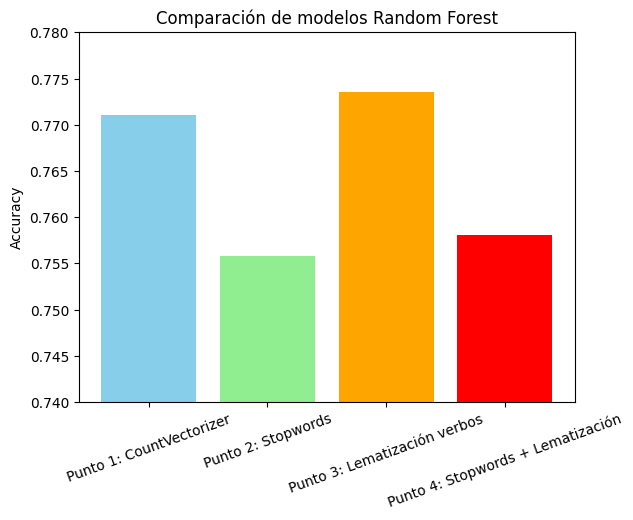

Punto 1 - CountVectorizer + RandomForest: 0.7711
Punto 2 - CountVectorizer (stopwords) + RandomForest: 0.7558
Punto 3 - CountVectorizer (lematización verbos) + RandomForest: 0.7736
Punto 4 - CountVectorizer (stopwords + lematización verbos) + RandomForest: 0.7581


In [45]:
accuracies = [acc_rf, acc_rf_sw, acc_rf_lem, acc_rf_lem_sw]
labels = [
    "Punto 1: CountVectorizer",
    "Punto 2: Stopwords",
    "Punto 3: Lematización verbos",
    "Punto 4: Stopwords + Lematización"
]

plt.bar(labels, accuracies, color=['skyblue','lightgreen','orange','red'])
plt.ylabel("Accuracy")
plt.title("Comparación de modelos Random Forest")
plt.ylim(0.74, 0.78)  # rango ajustado para ver diferencias
plt.xticks(rotation=20)
plt.show()

print(f"Punto 1 - CountVectorizer + RandomForest: {acc_rf:.4f}")
print(f"Punto 2 - CountVectorizer (stopwords) + RandomForest: {acc_rf_sw:.4f}")
print(f"Punto 3 - CountVectorizer (lematización verbos) + RandomForest: {acc_rf_lem:.4f}")
print(f"Punto 4 - CountVectorizer (stopwords + lematización verbos) + RandomForest: {acc_rf_lem_sw:.4f}")

<h3 style='color: deepskyblue;'>Conclusión</h3>

### Mejor modelo: CountVectorizer + Lematización de verbos (0.7736)

Este modelo obtuvo el mayor accuracy gracias al uso de la lematización de verbos, la cual normaliza las distintas formas verbales a su forma base. Esto permite que el modelo generalice mejor, ya que agrupa variantes morfológicas bajo un mismo término, reduciendo la dispersión del vocabulario sin perder información semántica relevante.

Adicionalmente al **no eliminar stopwords**, el modelo conserva palabras como "not" y "no", que son fundamentales para identificar la polaridad del sentimiento, especialmente en la diferenciación entre opiniones negativas y positivas.

### Peor modelo: CountVectorizer + Stopwords + Lematización (0.7557)

Este modelo presentó el menor desempeño, lo cual puede explicarse por la combinación de técnicas de preprocesamiento. La eliminación de stopwords descarta palabras clave como negaciones e intensificadores (“not”, “very”), que son esenciales en tareas de análisis de sentimientos. Por su parte, la lematización no logra compensar la pérdida de esta información crítica.

Además, considerando que los tweets son textos cortos e informales, la eliminación de stopwords reduce de manera agresiva el vocabulario disponible, limitando las señales que el modelo puede utilizar para diferenciar entre sentimientos negativos, neutros y positivos. Esto se traduce en un menor desempeño en términos de accuracy.